In [12]:
# ------------------ PHASE 0: PREPARATION ------------------

# ------------------ Library ------------------
import pandas as pd
import numpy as np
import os
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from scipy.stats import f_oneway, kruskal, zscore
from collections import Counter

sns.set(style="whitegrid")

# ------------------ Config ------------------
TRAIN_PATH = "../data/proteinas_train.csv"
EDA_DIR = "../eda/eda_outputs"
ARTIFACT_DIR = "../preprocessing/preprocessing_artifacts"
MODEL_DIR = "../models"
MAX_LEN = 300
EMBEDDING_DIM = 64
LSTM_UNITS = 64
DROPOUT_RATE = 0.2
os.makedirs(EDA_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------ Load & Clean ------------------
df = pd.read_csv(TRAIN_PATH)

column_map = {
    "ID_Proteína": "Protein_ID", "Sequência": "Sequence",
    "Massa_Molecular": "Molecular_Mass", "Ponto_Isoelétrico": "Isoelectric_Point",
    "Hidrofobicidade": "Hydrophobicity", "Carga_Total": "Total_Charge",
    "Proporção_Polar": "Polar_Proportion", "Proporção_Apolar": "Nonpolar_Proportion",
    "Comprimento_Sequência": "Sequence_Length", "Classe": "Class"
}

df.rename(columns=column_map, inplace=True)
df.columns = df.columns.str.strip()
df["Class"] = df["Class"].str.strip().astype("category")

numerical_features = [
    "Molecular_Mass", "Isoelectric_Point", "Hydrophobicity",
    "Total_Charge", "Polar_Proportion", "Nonpolar_Proportion", "Sequence_Length"
]

In [ ]:
# ------------------ PHASE 1: EDA ------------------

# --- Class Distribution ---
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.savefig(f"{EDA_DIR}/class_distribution.png")
plt.clf()

# --- Numeric Distributions ---
for col in numerical_features:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.savefig(f"{EDA_DIR}/{col}_distribution.png")
    plt.clf()

# --- Correlation Heatmaps ---
pearson_corr = df[numerical_features].corr("pearson")
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm")
plt.title("Pearson Correlation")
plt.savefig(f"{EDA_DIR}/correlation_pearson.png")
plt.clf()

spearman_corr = df[numerical_features].corr("spearman")
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation")
plt.savefig(f"{EDA_DIR}/correlation_spearman.png")
plt.clf()

# --- ANOVA / Kruskal and Boxplots ---
for col in numerical_features:
    groups = [g[col].values for _, g in df.groupby("Class")]
    try:
        stat, p = f_oneway(*groups)
    except:
        stat, p = kruskal(*groups)
    sns.boxplot(data=df, x="Class", y=col)
    plt.title(f"{col} by Class (p = {p:.3e})")
    plt.xticks(rotation=45)
    plt.savefig(f"{EDA_DIR}/{col}_by_class.png")
    plt.clf()

# --- Amino Acid Frequency ---
aa_counter = Counter("".join(df["Sequence"]))
aa_freq = pd.DataFrame.from_dict(aa_counter, orient="index", columns=["Count"])
aa_freq = aa_freq.sort_values("Count", ascending=False)
sns.barplot(x=aa_freq.index[:20], y=aa_freq["Count"][:20])
plt.title("Top 20 Most Frequent Amino Acids")
plt.savefig(f"{EDA_DIR}/aa_frequency_top20.png")
plt.clf()

# --- Outlier Check ---
z_scores = df[numerical_features].apply(zscore)
outliers = df[(z_scores.abs() > 3).any(axis=1)]
print(f"Outliers (|z| > 3): {outliers.shape[0]}")

# --- Biological Sanity Check ---
bad_polarity = df[(df["Polar_Proportion"] + df["Nonpolar_Proportion"]) > 1.0]
print(f"Inconsistent polarity rows: {bad_polarity.shape[0]}")
bad_charge = df[(df["Total_Charge"].abs() > 40) & (df["Sequence_Length"] < 100)]
print(f"Extreme charge in short sequences: {bad_charge.shape[0]}")

# --- PCA Projection ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_features])
y = df['Class']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, alpha=0.6)
plt.title("PCA (2D) Projection of Numerical Features")
plt.savefig(f"{EDA_DIR}/pca_projection.png")
plt.clf()

# --- t-SNE on Sample ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_sample = df.sample(n=2000, random_state=42)
X_sample = scaler.transform(df_sample[numerical_features])
X_tsne = tsne.fit_transform(X_sample)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_sample["Class"])
plt.title("t-SNE (2D) on Sampled Numerical Features")
plt.savefig(f"{EDA_DIR}/tsne_projection.png")
plt.clf()

C:\Users\arvyn\AppData\Local\Temp\ipykernel_17164\2291598841.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[col].values for _, g in df.groupby("Class")]
C:\Users\arvyn\AppData\Local\Temp\ipykernel_17164\2291598841.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[col].values for _, g in df.groupby("Class")]
C:\Users\arvyn\AppData\Local\Temp\ipykernel_17164\2291598841.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

Outliers (|z| > 3): 357
Inconsistent polarity rows: 0
Extreme charge in short sequences: 0


<Figure size 640x480 with 0 Axes>

In [ ]:
# ------------------ PHASE 2: PREPROCESSING ------------------

# ------------------ Feature Engineering ------------------

# Basic features (original numeric)
base_features = [
    "Molecular_Mass", "Isoelectric_Point", "Hydrophobicity",
    "Total_Charge", "Polar_Proportion", "Nonpolar_Proportion", "Sequence_Length"
]

# Engineered features
df["Charge_Density"] = df["Total_Charge"] / df["Sequence_Length"]
df["Hydrophobicity_x_Polar"] = df["Hydrophobicity"] * df["Polar_Proportion"]
df["Log_Mass"] = np.log1p(df["Molecular_Mass"])
df["PI_per_Length"] = df["Isoelectric_Point"] / df["Sequence_Length"]

# Binned feature: Isoelectric Point group
df["PI_Group"] = pd.cut(df["Isoelectric_Point"], bins=[0, 6.5, 8, 12], labels=["acidic", "neutral", "basic"])

# Flag: extremely short sequence
df["Is_Short_Seq"] = (df["Sequence_Length"] < 100).astype(int)

# Flag: high charge
df["Is_High_Charge"] = (df["Total_Charge"] > 20).astype(int)

# New feature list
engineered_features = [
    "Charge_Density", "Hydrophobicity_x_Polar", "Log_Mass",
    "PI_per_Length", "Is_Short_Seq", "Is_High_Charge"
]

# Include one-hot encoding of PI_Group
df = pd.get_dummies(df, columns=["PI_Group"], drop_first=True)

# Final feature list to use
final_features = base_features + engineered_features + list(df.columns[df.columns.str.startswith("PI_Group_")])

# Preview final engineered features
df_final = df[["Protein_ID", "Class"] + final_features].head()

# ------------------ Label Encoding ------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["Class"])

# ------------------ Numeric Scaling ------------------
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[final_features])

# ------------------ Sequence Tokenization ------------------
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df["Sequence"])
X_seq_tokenized = tokenizer.texts_to_sequences(df["Sequence"])
X_seq_padded = pad_sequences(X_seq_tokenized, maxlen=MAX_LEN, padding='post')

# ------------------ Stratified Train-Validation Split ------------------
X_num_train, X_num_val, X_seq_train, X_seq_val, y_train, y_val = train_test_split(
    X_num_scaled, X_seq_padded, y_encoded,
    test_size=0.2, stratify=y_encoded, random_state=42
)

# ------------------ Save Artifacts ------------------
# Scaler and label encoder
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(ARTIFACT_DIR, "label_encoder.pkl"))

# Tokenizer
with open(os.path.join(ARTIFACT_DIR, "tokenizer.json"), "w") as f:
    f.write(tokenizer.to_json())

# Class mapping
class_mapping = {cls: int(idx) for cls, idx in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))}
with open(os.path.join(ARTIFACT_DIR, "class_mapping.json"), "w") as f:
    json.dump(class_mapping, f)

# Engineered features
with open(os.path.join(ARTIFACT_DIR, "feature_list.json"), "w") as f:
    json.dump(final_features, f)

# Numpy arrays (optional)
np.save(os.path.join(ARTIFACT_DIR, "X_num_train.npy"), X_num_train)
np.save(os.path.join(ARTIFACT_DIR, "X_num_val.npy"), X_num_val)
np.save(os.path.join(ARTIFACT_DIR, "X_seq_train.npy"), X_seq_train)
np.save(os.path.join(ARTIFACT_DIR, "X_seq_val.npy"), X_seq_val)
np.save(os.path.join(ARTIFACT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(ARTIFACT_DIR, "y_val.npy"), y_val)

print("✅ Preprocessing complete.")
print(f"Artifacts saved to: {ARTIFACT_DIR}")
print(f"Train size: {X_num_train.shape[0]}, Validation size: {X_num_val.shape[0]}")
print(f"Feature count: {X_num_train.shape[1]}")
print(f"Total encoded classes: {len(label_encoder.classes_)}")

✅ Preprocessing complete.
Artifacts saved to: ../Data/preprocessing_artifacts
Train size: 12800, Validation size: 3200
Feature count: 15
Total encoded classes: 5



===== random_forest =====
Accuracy: 0.1919
Macro F1: 0.1919
Confusion Matrix:
[[123 136 143 101 144]
 [149 124 135 105 133]
 [138 124 121 125 129]
 [136 141 126 113 109]
 [146 129 122 115 133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.19      0.18       647
           1       0.19      0.19      0.19       646
           2       0.19      0.19      0.19       637
           3       0.20      0.18      0.19       625
           4       0.21      0.21      0.21       645

    accuracy                           0.19      3200
   macro avg       0.19      0.19      0.19      3200
weighted avg       0.19      0.19      0.19      3200

Model saved to: ../models/random_forest_model.pkl

===== xgboost =====


d:\KDS\kds_yok\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.1975
Macro F1: 0.1975
Confusion Matrix:
[[123 152 125 129 118]
 [125 133 132 123 133]
 [137 131 128 106 135]
 [116 146 123 120 120]
 [139 135 120 123 128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.19      0.19       647
           1       0.19      0.21      0.20       646
           2       0.20      0.20      0.20       637
           3       0.20      0.19      0.20       625
           4       0.20      0.20      0.20       645

    accuracy                           0.20      3200
   macro avg       0.20      0.20      0.20      3200
weighted avg       0.20      0.20      0.20      3200

Model saved to: ../models/xgboost_model.pkl

===== logistic_regression =====


d:\KDS\kds_yok\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.1981
Macro F1: 0.1904
Confusion Matrix:
[[167 172 142  42 124]
 [147 161 151  59 128]
 [155 160 152  54 116]
 [160 161 148  47 109]
 [163 178 151  46 107]]

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.26      0.23       647
           1       0.19      0.25      0.22       646
           2       0.20      0.24      0.22       637
           3       0.19      0.08      0.11       625
           4       0.18      0.17      0.17       645

    accuracy                           0.20      3200
   macro avg       0.20      0.20      0.19      3200
weighted avg       0.20      0.20      0.19      3200

Model saved to: ../models/logistic_regression_model.pkl


100%|===================| 999/1000 [02:52<00:00]        

SHAP summary plot saved.


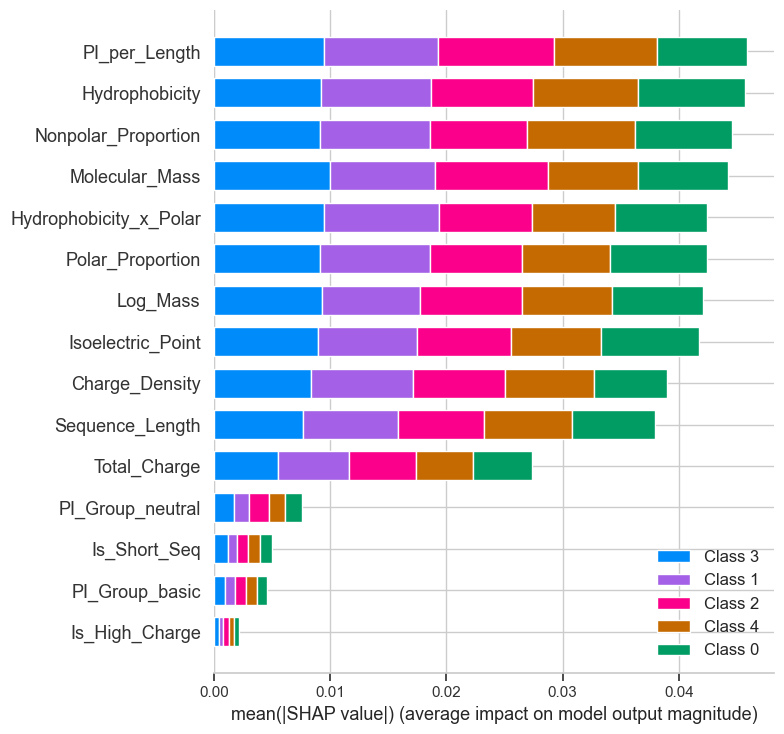

In [ ]:
# ------------------ PHASE 3: PREPROCESSING TABULAR MODEL ------------------

# ------------------ Load Artifacts ------------------
X_train = np.load(os.path.join(ARTIFACT_DIR, "X_num_train.npy"))
X_val = np.load(os.path.join(ARTIFACT_DIR, "X_num_val.npy"))
y_train = np.load(os.path.join(ARTIFACT_DIR, "y_train.npy"))
y_val = np.load(os.path.join(ARTIFACT_DIR, "y_val.npy"))

with open(os.path.join(ARTIFACT_DIR, "feature_list.json")) as f:
    feature_names = json.load(f)

# ------------------ Model Training ------------------
def train_evaluate_model(model, name):
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    joblib.dump(model, os.path.join(MODEL_DIR, f"{name}_model.pkl"))
    print(f"Model saved to: {MODEL_DIR}/{name}_model.pkl")

    return model

# ------------------ Models ------------------
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')

# ------------------ Train & Evaluate ------------------
rf_model = train_evaluate_model(rf, "random_forest")
xgb_model = train_evaluate_model(xgb, "xgboost")
logreg_model = train_evaluate_model(logreg, "logistic_regression")

# ------------------ Feature Importance (SHAP for RF) ------------------
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_train[:200])
shap.summary_plot(shap_values, features=X_train[:200], feature_names=feature_names, show=False)
plt.savefig(os.path.join(MODEL_DIR, "shap_summary_rf.png"))
print("SHAP summary plot saved.")

d:\KDS\kds_yok\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
400/400 - 51s - 126ms/step - accuracy: 0.2004 - loss: 1.6101 - val_accuracy: 0.2013 - val_loss: 1.6093
Epoch 2/15
400/400 - 41s - 104ms/step - accuracy: 0.1991 - loss: 1.6100 - val_accuracy: 0.2059 - val_loss: 1.6098
Epoch 3/15
400/400 - 43s - 107ms/step - accuracy: 0.1997 - loss: 1.6100 - val_accuracy: 0.1997 - val_loss: 1.6095
Epoch 4/15
400/400 - 72s - 179ms/step - accuracy: 0.2052 - loss: 1.6097 - val_accuracy: 0.2037 - val_loss: 1.6093
Epoch 5/15
400/400 - 56s - 140ms/step - accuracy: 0.2077 - loss: 1.6090 - val_accuracy: 0.2006 - val_loss: 1.6097
Epoch 6/15
400/400 - 39s - 97ms/step - accuracy: 0.2098 - loss: 1.6086 - val_accuracy: 0.2044 - val_loss: 1.6096
Epoch 7/15
400/400 - 52s - 129ms/step - accuracy: 0.2150 - loss: 1.6079 - val_accuracy: 0.1991 - val_loss: 1.6107
Epoch 8/15
400/400 - 83s - 208ms/step - accuracy: 0.2130 - loss: 1.6076 - val_accuracy: 0.2072 - val_loss: 1.6099
Epoch 9/15
400/400 - 88s - 220ms/step - accuracy: 0.2210 - loss: 1.6061 - val_accuracy: 0

Accuracy: 0.2037
Macro F1: 0.1885
Confusion Matrix:
[[237 106 186  29  89]
 [249  78 165  44 110]
 [235  90 188  30  94]
 [255  86 151  45  88]
 [242  94 166  39 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.37      0.25       647
           1       0.17      0.12      0.14       646
           2       0.22      0.30      0.25       637
           3       0.24      0.07      0.11       625
           4       0.21      0.16      0.18       645

    accuracy                           0.20      3200
   macro avg       0.21      0.20      0.19      3200
weighted avg       0.21      0.20      0.19      3200

Model saved to ../models/sequence_model_bilstm.h5
Loss curve saved.


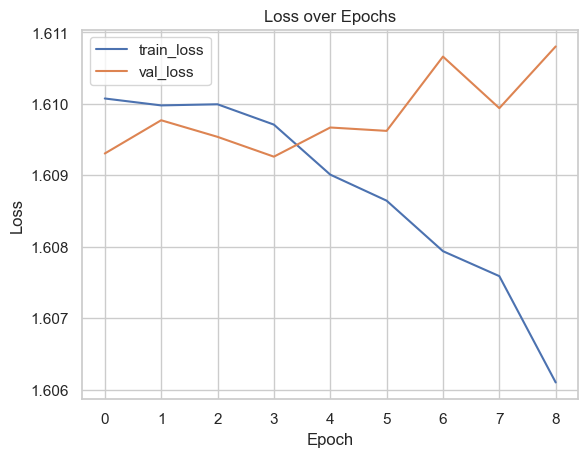

In [13]:
# ------------------ PHASE 4: PREPROCESSING SEQUENCE MODEL ------------------\

# ------------------ Load Artifacts ------------------
X_train = np.load(os.path.join(ARTIFACT_DIR, "X_seq_train.npy"))
X_val = np.load(os.path.join(ARTIFACT_DIR, "X_seq_val.npy"))
y_train = np.load(os.path.join(ARTIFACT_DIR, "y_train.npy"))
y_val = np.load(os.path.join(ARTIFACT_DIR, "y_val.npy"))

with open(os.path.join(ARTIFACT_DIR, "tokenizer.json")) as f:
    tokenizer_data = json.load(f)
vocab_size = len(tokenizer_data["config"]["word_index"]) + 1

# ------------------ Build Model ------------------
def build_model():
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(Bidirectional(LSTM(units=LSTM_UNITS, dropout=DROPOUT_RATE, return_sequences=False)))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(5, activation='softmax'))  # 5 protein classes
    return model

model = build_model()
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ------------------ Training ------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=15,
    callbacks=[early_stop],
    verbose=2
)

# ------------------ Evaluation ------------------
y_pred = model.predict(X_val)
y_pred_labels = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_val, y_pred_labels)
f1 = f1_score(y_val, y_pred_labels, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_labels))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_labels))

# ------------------ Save Model ------------------
model.save(os.path.join(MODEL_DIR, "sequence_model_bilstm.h5"))
print(f"Model saved to {MODEL_DIR}/sequence_model_bilstm.h5")

# ------------------ Plot Loss ------------------
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(MODEL_DIR, "sequence_model_loss_curve.png"))
print("Loss curve saved.")
